# Objective: Image Denoising using a Deep Learning Autoencoder on the MNIST Dataset

### Name – Rashali Bajaj
### Internship Assessment – Week 6




In [1]:
# Numerical computations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Load and Explore the MNIST Dataset

In this step, we load the dataset, examine its structure, and verify that it has been loaded correctly before preprocessing.

In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Display dataset information
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

print("\nImage Dimensions :", x_train.shape[1], "x", x_train.shape[2])

print("\nPixel Value Range")
print("Minimum Pixel Value :", x_train.min())
print("Maximum Pixel Value :", x_train.max())

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Image Dimensions : 28 x 28

Pixel Value Range
Minimum Pixel Value : 0
Maximum Pixel Value : 255


### Dataset Observations

- The dataset contains **60,000 training images** and **10,000 testing images**.
- Each image is a **28 × 28 grayscale image**.
- The labels represent handwritten digits from **0 to 9**.
- Pixel values range from **0 to 255**, which will be normalized before training the Autoencoder.

## Visualize Sample Images

Before preprocessing the dataset, it is important to visualize a few sample images. This helps verify that the dataset has been loaded correctly and provides an understanding of the handwritten digit images that will be used to train the Denoising Autoencoder.

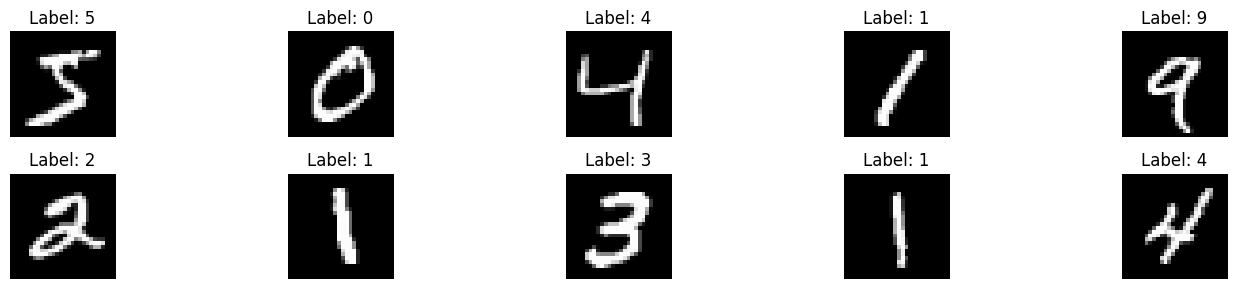

In [4]:
import matplotlib.pyplot as plt

# Display the first 10 training images
plt.figure(figsize=(15, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations

- Each image has a resolution of **28 × 28 pixels**.
- The labels correctly correspond to the handwritten digits displayed.


## Data Preprocessing

Before training the Denoising Autoencoder, the images need to be preprocessed.

The preprocessing steps include:

- **Normalization:** Pixel values are scaled from the range **0–255** to **0–1**. This improves numerical stability and helps the neural network converge faster during training.
- **Reshaping:** Since convolutional neural networks expect images with a channel dimension, the images are reshaped from **(28, 28)** to **(28, 28, 1)**.

In [5]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images for CNN
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# Display updated shapes
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape :", x_test.shape)

print("\nPixel Value Range")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Training Data Shape: (60000, 28, 28, 1)
Testing Data Shape : (10000, 28, 28, 1)

Pixel Value Range
Minimum: 0.0
Maximum: 1.0


### Observations

- The images have been reshaped to include a single channel, resulting in a dataset shape of **(60000, 28, 28, 1)** for training and **(10000, 28, 28, 1)** for testing.

## Artificial Noise Generation

To train a Denoising Autoencoder, artificial Gaussian noise is added to the original images. The noisy images are used as the input to the model, while the corresponding clean images serve as the target output.

Gaussian noise simulates real-world image corruption and enables the Autoencoder to learn how to reconstruct clean images from noisy inputs.

After adding noise, pixel values are clipped to the valid range **[0, 1]** to maintain valid grayscale image intensities.

In [6]:
# Set the noise level
noise_factor = 0.5

# Add Gaussian noise
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Clip pixel values to the range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise successfully added!")

Noise successfully added!


## Visual Comparison of Original and Noisy Images

The following visualization compares the original MNIST images with their noisy counterparts. This helps verify that artificial noise has been added successfully before training the Autoencoder.

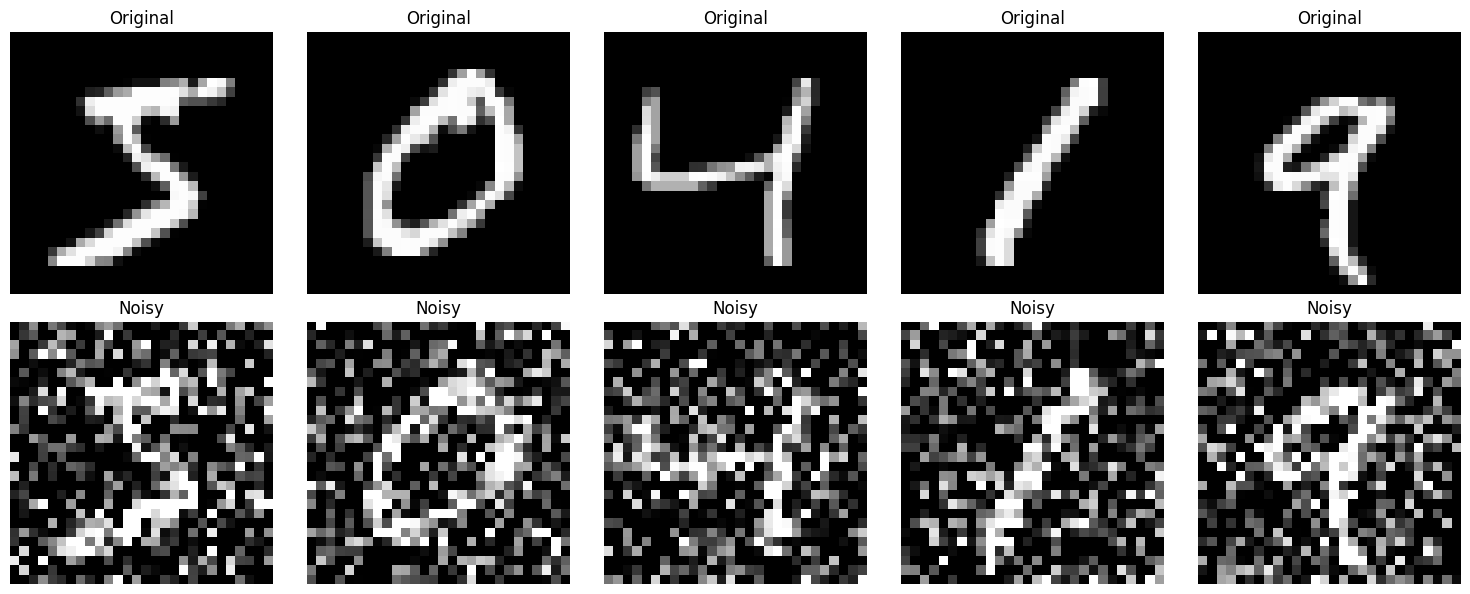

In [7]:
plt.figure(figsize=(15, 6))

for i in range(5):

    # Original Image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations

- The noisy images retain the overall digit structure but contain random pixel disturbances.
- Gaussian noise has been successfully introduced without altering the image dimensions.
- These noisy images will be used as input to the Autoencoder, while the original clean images will serve as the target output during training.

## Build the Denoising Autoencoder

The Denoising Autoencoder consists of two parts:

- **Encoder:** Extracts important features and compresses the input image.
- **Decoder:** Reconstructs a clean image from the compressed representation.

The model learns to remove noise while preserving the digit structure.

In [8]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Input Layer
input_img = Input(shape=(28, 28, 1))

# ---------------- Encoder ----------------
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# ---------------- Decoder ----------------
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Build the Autoencoder
autoencoder = Model(input_img, decoded)

In [9]:
# Display the model architecture
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the Model

The Autoencoder is compiled using the **Adam optimizer** and **Binary Crossentropy** loss. The model is trained using noisy images as input and the original clean images as the target output.

In [10]:
# Compile the Autoencoder
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [11]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 264ms/step - loss: 0.1600 - val_loss: 0.1153
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 260ms/step - loss: 0.1124 - val_loss: 0.1081
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 257ms/step - loss: 0.1076 - val_loss: 0.1051
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 259ms/step - loss: 0.1050 - val_loss: 0.1030
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 265ms/step - loss: 0.1032 - val_loss: 0.1013
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 253ms/step - loss: 0.1018 - val_loss: 0.1003
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 253ms/step - loss: 0.1008 - val_loss: 0.0994
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 257ms/step - loss: 0.1000 - val_loss: 0.0988
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 254ms/step - loss: 0.0994 - val_loss: 0.0983
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 253ms/step - loss: 0.0989 - val_loss: 0.0978
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 253ms/step - loss: 0.0984 - val_loss: 0.0974
Epoch 12

### Observations

- The model learns to reconstruct clean images from noisy inputs.
- Training and validation losses indicate how well the model generalizes.
- Lower loss values represent better image reconstruction.

## Training Performance

The training and validation loss curves illustrate the learning progress of the Denoising Autoencoder throughout the training process.

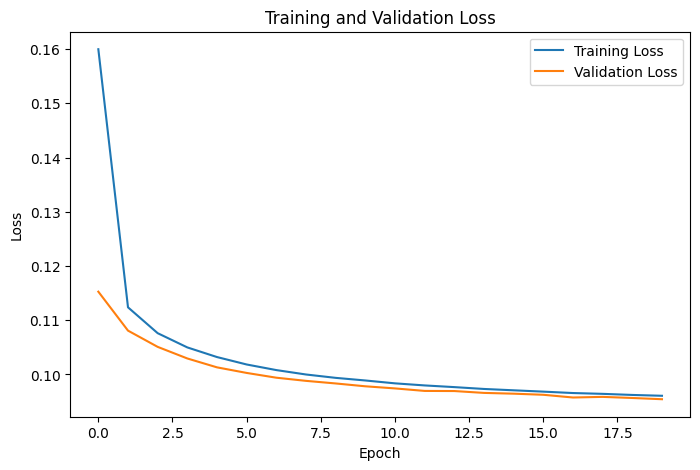

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Image Reconstruction

The trained Autoencoder is used to reconstruct clean images from the noisy test images.

In [13]:
# Generate denoised images
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


## Results

The following figure compares the original, noisy, and reconstructed images produced by the Denoising Autoencoder.

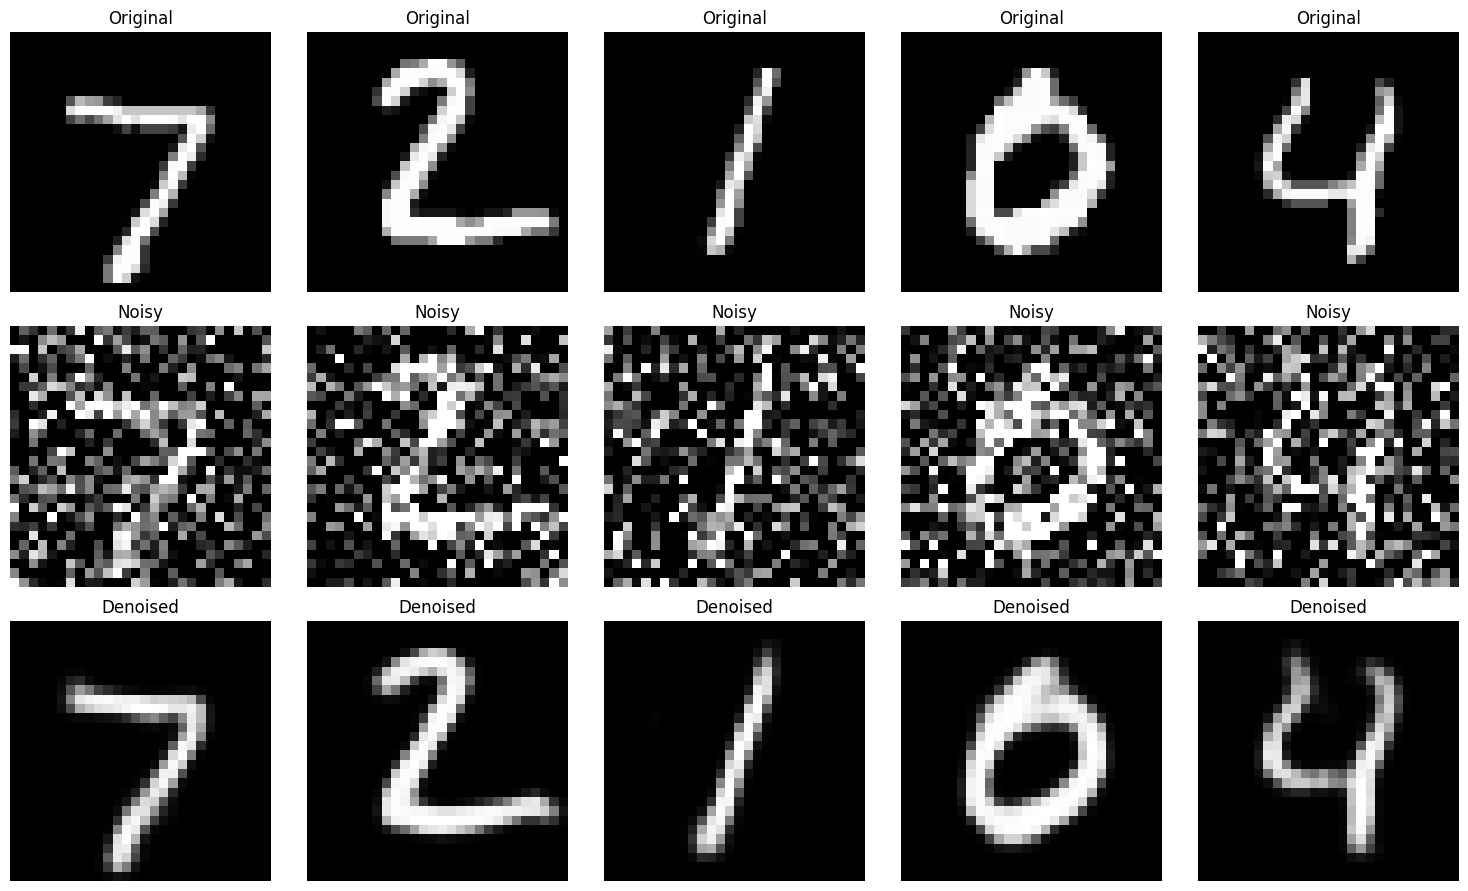

In [14]:
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observations

- The Autoencoder successfully reduced noise while preserving the digit structure.
- The reconstructed images are significantly cleaner than the noisy inputs.
- The model demonstrates the effectiveness of Autoencoders for image denoising tasks.

## Conclusion

A Convolutional Denoising Autoencoder was successfully developed to remove Gaussian noise from MNIST handwritten digit images. The model learned meaningful latent representations and reconstructed clean images with low reconstruction loss, demonstrating its effectiveness for image denoising.